Dataset extracted to /content/House_Price_Dataset_extracted
Dataset loaded successfully.

--- Dataset Shape ---
(20640, 10)

--- Dataset dtypes ---
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

--- Dataset Description ---
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118

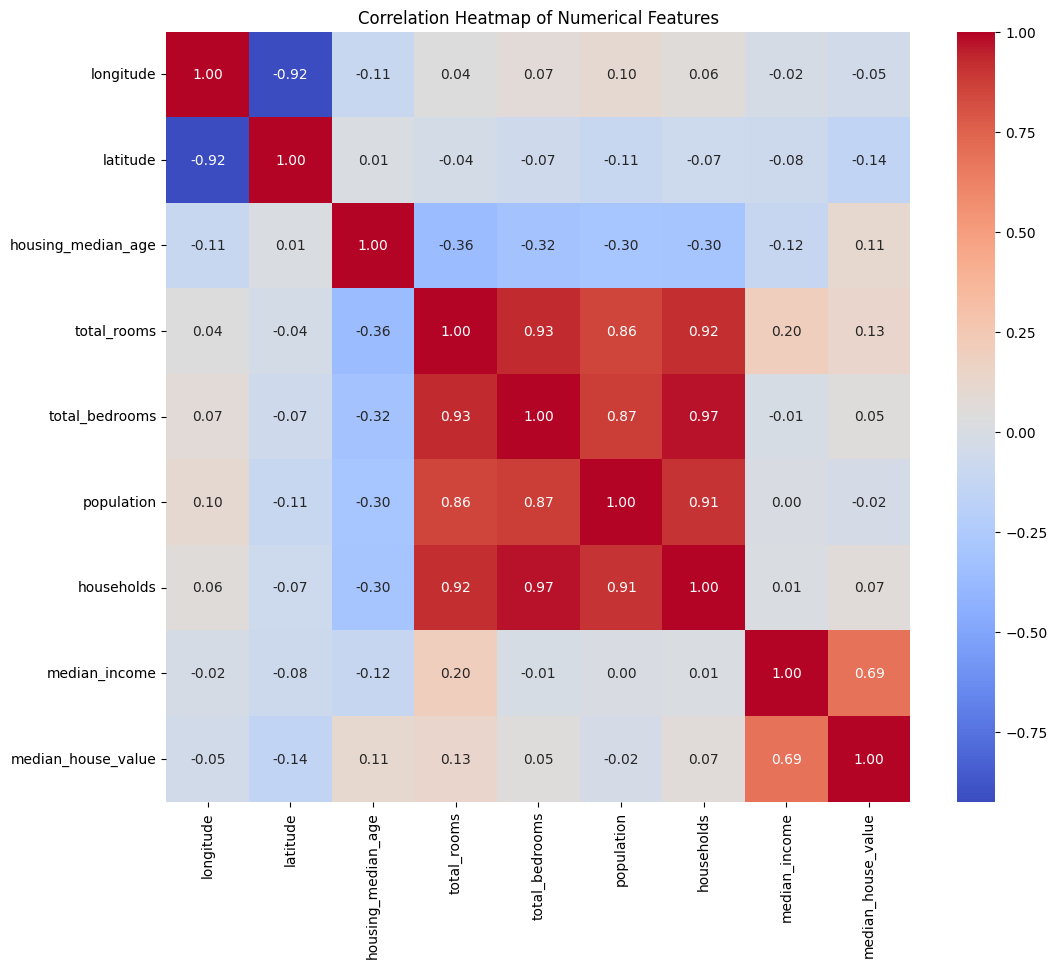

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import joblib
import zipfile
import os

# Assuming csv_file_path is already defined in the kernel as '/content/House_Price_Dataset_extracted/housing.csv'
# If not, uncomment the line below and set the path manually:
# csv_file_path = '/content/House_Price_Dataset_extracted/housing.csv'

# 1. DATA PREPROCESSING
# Extract the zip file first
# Assuming zip_file_path and extract_dir are defined from the kernel state.
# If not, define them here:
# zip_file_path = '/content/House Price Dataset.zip'
# extract_dir = '/content/House_Price_Dataset_extracted'

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"Dataset extracted to {extract_dir}")

# Load the dataset
df = pd.read_csv(csv_file_path)
print("Dataset loaded successfully.")

# Basic EDA
print("\n--- Dataset Shape ---")
print(df.shape)

print("\n--- Dataset dtypes ---")
print(df.dtypes)

print("\n--- Dataset Description ---")
print(df.describe())

print("\n--- Null Counts ---")
print(df.isnull().sum())

# Identify target variable (assuming 'median_house_value' for California Housing)
target = 'median_house_value'
features = df.drop(columns=[target]).columns

# Separate features and target
X = df[features]
y = df[target]

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=np.number).columns

print(f"\nCategorical features: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")

# Preprocessing pipelines for numerical and categorical features
# Impute missing numerical values with the mean and then scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Impute missing categorical values with the most frequent and then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any, though usually not needed after this setup
)

# Fit and transform the data
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# This is a bit tricky with ColumnTransformer, so we'll get it from the one-hot encoder step
# First, get the feature names from the numerical features, and then from the one-hot encoded categorical features
feature_names = list(numerical_features)
if len(categorical_features) > 0:
    ohe_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    feature_names.extend(ohe_feature_names)

X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

print("\n--- Data after Preprocessing (first 5 rows) ---")
print(X_processed_df.head())

print("\n--- Correlation Heatmap ---")
# For the correlation heatmap, we will use the original dataframe with imputed values
# as X_processed_df contains scaled values which are better for modeling, but original for initial correlation insights
df_corr = df.copy()
for col in numerical_features:
    if df_corr[col].isnull().any():
        df_corr[col] = SimpleImputer(strategy='mean').fit_transform(df_corr[[col]])

# Drop original categorical features for correlation calculation, as they will be one-hot encoded later
# For heatmap, let's include target variable to see its correlation with features
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 2. FEATURE SELECTION

In [51]:
# 2. FEATURE SELECTION

# --- Method 1: SelectKBest (using f_regression for numerical features) ---
# This is suitable for regression tasks and numerical features.
# Note: With one-hot encoded categorical features, f_regression can still provide a score for each dummy variable.

# Select top features based on f_regression scores
k_best = SelectKBest(score_func=f_regression, k=10) # Select top 10 features
k_best.fit(X_processed_df, y)

selected_features_kbest_indices = k_best.get_support(indices=True)
selected_features_kbest = X_processed_df.columns[selected_features_kbest_indices]

print("\n--- Features selected by SelectKBest (Top 10) ---")
print(list(selected_features_kbest))

# --- Method 2: Feature Importance from a Random Forest Model ---
# Train a simple Random Forest Regressor to get feature importances
# This model will serve to identify important features, not for final prediction yet.
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X_processed_df, y)

feature_importances = pd.Series(rf_selector.feature_importances_, index=X_processed_df.columns)
feature_importances_sorted = feature_importances.sort_values(ascending=False)

print("\n--- Feature Importances from Random Forest (Top 15) ---")
print(feature_importances_sorted.head(15))

# Drop low-importance features (using a threshold, e.g., 1% of max importance or absolute value)
# Let's set a dynamic threshold based on the mean importance
importance_threshold = feature_importances_sorted.mean() / 2 # Using half of the mean importance as a threshold

final_selected_features = feature_importances_sorted[feature_importances_sorted > importance_threshold].index.tolist()

# Ensure target is not in features (though it shouldn't be)
if target in final_selected_features:
    final_selected_features.remove(target)

# Check for highly correlated features among the *selected* features and drop one
# This helps in reducing multicollinearity in the final model if needed.
selected_df = X_processed_df[final_selected_features]
correlation_matrix = selected_df.corr().abs()
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)] # Threshold 0.9 for high correlation

final_selected_features_filtered = [f for f in final_selected_features if f not in to_drop]

print(f"\n--- Dropped {len(to_drop)} highly correlated features from selected features: {to_drop} ---")

# Update X_processed_df to only include the final selected features
X_final = X_processed_df[final_selected_features_filtered]

print("\n--- Final Selected Features ---")
print(list(X_final.columns))
print(f"Number of final selected features: {len(X_final.columns)}")


--- Features selected by SelectKBest (Top 10) ---
['latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

--- Feature Importances from Random Forest (Top 15) ---
median_income                 0.482625
ocean_proximity_INLAND        0.143708
longitude                     0.110975
latitude                      0.105462
housing_median_age            0.051000
population                    0.030494
total_rooms                   0.024342
total_bedrooms                0.021159
households                    0.018829
ocean_proximity_NEAR OCEAN    0.006393
ocean_proximity_<1H OCEAN     0.003598
ocean_proximity_NEAR BAY      0.001040
ocean_proximity_ISLAND        0.000373
dtype: float64

--- Dropped 1 highly correlated features from selected features: ['latitude'] ---

--- Final Selected Features ---
['median_income', 'ocean_proximity_INLAND'

### 3. TRAIN/TEST SPLIT

In [52]:
# 3. TRAIN/TEST SPLIT
# Split data 80/20 using train_test_split (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Print shapes of X_train, X_test, y_train, y_test
print("--- Shapes of Training and Testing Data ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

--- Shapes of Training and Testing Data ---
X_train shape: (16512, 4)
X_test shape: (4128, 4)
y_train shape: (16512,)
y_test shape: (4128,)


### 4. MODEL TRAINING

In [53]:
# 4. MODEL TRAINING

# Dictionary to store models and their predictions
models = {}
predictions = {}

# a) Linear Regression
print("\n--- Training Linear Regression Model ---")
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
models['Linear Regression'] = linear_reg
predictions['Linear Regression'] = linear_reg.predict(X_test)
print("Linear Regression Model trained.")

# b) Decision Tree Regressor
print("\n--- Training Decision Tree Regressor ---")
decision_tree_reg = DecisionTreeRegressor(random_state=42)
decision_tree_reg.fit(X_train, y_train)
models['Decision Tree Regressor'] = decision_tree_reg
predictions['Decision Tree Regressor'] = decision_tree_reg.predict(X_test)
print("Decision Tree Regressor trained.")

# c) Random Forest Regressor
print("\n--- Training Random Forest Regressor ---")
random_forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_reg.fit(X_train, y_train)
models['Random Forest Regressor'] = random_forest_reg
predictions['Random Forest Regressor'] = random_forest_reg.predict(X_test)
print("Random Forest Regressor trained.")

print("\nAll models trained and predictions made.")


--- Training Linear Regression Model ---
Linear Regression Model trained.

--- Training Decision Tree Regressor ---
Decision Tree Regressor trained.

--- Training Random Forest Regressor ---
Random Forest Regressor trained.

All models trained and predictions made.


### 5. EVALUATION


--- Model Evaluation ---

--- Linear Regression ---
  MAE: 53529.41
  RMSE: 74131.80
  R² Score: 0.58

--- Decision Tree Regressor ---
  MAE: 54487.23
  RMSE: 83408.52
  R² Score: 0.47

--- Random Forest Regressor ---
  MAE: 42737.27
  RMSE: 63904.49
  R² Score: 0.69


/tmp/ipykernel_1470/3580408386.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=rmse_scores, palette='viridis')


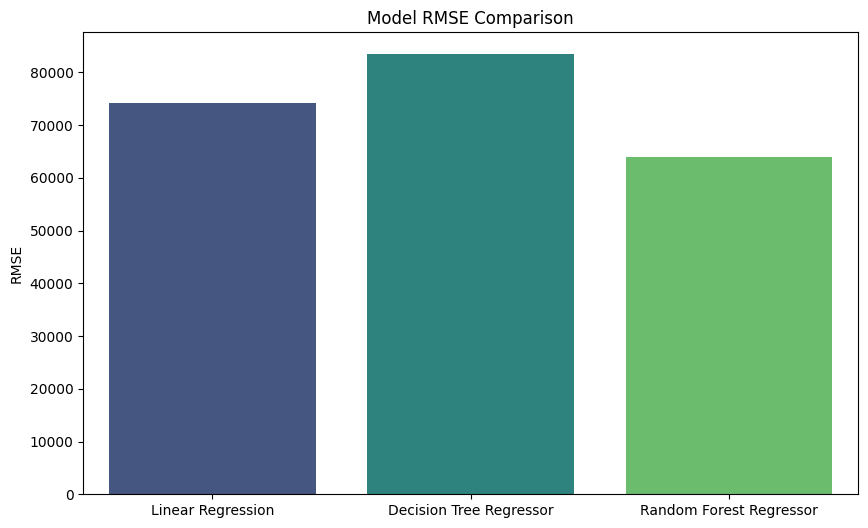

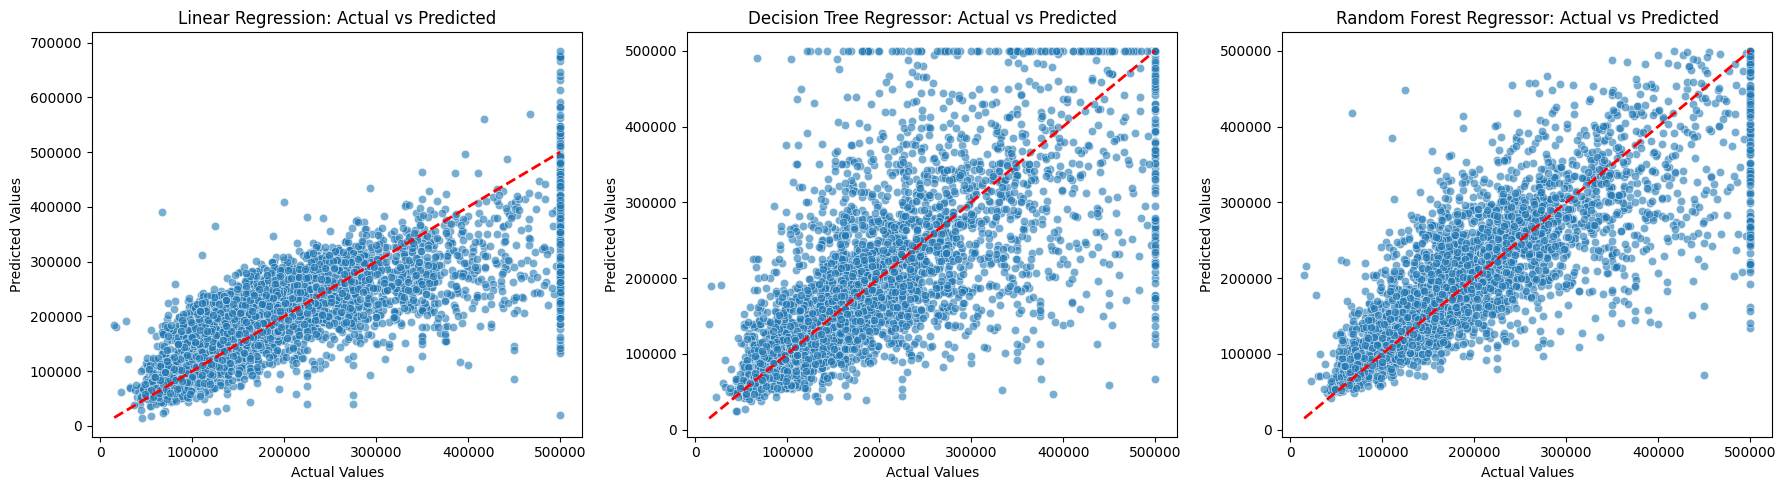

In [54]:
# 5. EVALUATION

# Dictionary to store evaluation results
evaluation_results = {}

print("\n--- Model Evaluation ---")
for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    evaluation_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2 Score': r2}

    print(f"\n--- {name} ---")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R² Score: {r2:.2f}")

# Plot a comparison bar chart of model performance (RMSE)
model_names = list(evaluation_results.keys())
rmse_scores = [results['RMSE'] for results in evaluation_results.values()]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=rmse_scores, palette='viridis')
plt.title('Model RMSE Comparison')
plt.ylabel('RMSE')
plt.show()

# Plot Actual vs Predicted for regression models
plt.figure(figsize=(18, 5))
for i, (name, y_pred) in enumerate(predictions.items()):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
    plt.title(f'{name}: Actual vs Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
plt.tight_layout()
plt.show()

### 6. OUTPUT

In [55]:
# 6. OUTPUT

# Create a DataFrame for the summary table
summary_df = pd.DataFrame(evaluation_results).T
print("\n--- Model Performance Summary ---")
print(summary_df)

# Highlight the best performing model based on RMSE (lower is better)
best_model_name = summary_df['RMSE'].idxmin()
best_model_rmse = summary_df['RMSE'].min()

print(f"\n--- Best Performing Model ---")
print(f"The best model based on RMSE is: {best_model_name} with RMSE = {best_model_rmse:.2f}")

# Save the best model using joblib
best_model = models[best_model_name]
joblib.dump(best_model, 'best_model.pkl')
print(f"\nBest model ('{best_model_name}') saved as 'best_model.pkl'.")


--- Model Performance Summary ---
                                  MAE          RMSE  R2 Score
Linear Regression        53529.405318  74131.799187  0.580625
Decision Tree Regressor  54487.229893  83408.521268  0.469098
Random Forest Regressor  42737.274974  63904.490779  0.688358

--- Best Performing Model ---
The best model based on RMSE is: Random Forest Regressor with RMSE = 63904.49

Best model ('Random Forest Regressor') saved as 'best_model.pkl'.
